<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/GLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generalized Linear Models Setup

## Video Reviews

Quant Psych
* Understanding GLM - https://www.youtube.com/watch?v=SqN-qlQOM5A
* GLM Pt 1 - https://www.youtube.com/watch?v=ZWnM-yPUXlA
* GLM Pt 2 - https://www.youtube.com/watch?v=29Droau_6DM


Stanford
* https://www.youtube.com/watch?v=LvySJGj-88U&list=PLoROMvodv4rPP6braWoRt5UCXYZ71GZIQ
GLM - 4.8

## Types of Regression

* More Regression Notebook

## Concepts vs Facts

Concepts are an efficient way to store knowledge. Oncel you have abstracted the common features of a concept such as chair, you will recognize objects you have never seen before as a type of chair. This is because you hold in memory a prototypic representation of the concept - an abstraction of "chairness." Unfortunately, facts must each be held in memory individually. This is because they have no common group features. By definition, a fact is a unique piece of information that must be individually held in memory to be known. Compared to concepts, facts are a much less efficient form of knowledge.

Developing Technical Training: A Structured Approach for Developing Classroom and Computer-Based Instructional Materials 3rd Edition by Ruth Clark https://www.amazon.com/Developing-Technical-Training-Computer-based-Instructional/dp/0787988464

## Functions

### Examples

* See Functions Notebook

## Distributions

### Distribution Plots and Shapiro-Wilk Test (Normal)

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6676026/#:~:text=The%20purpose%20of%20the%20t,essential%20in%20the%20t%2Dtest

The Shapiro–Wilk test is a test of normality. It was published in 1965 by Samuel Sanford Shapiro and Martin Wilk.

https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test

If the p-value of the test is greater than α = .05, then the data is assumed to be normally distributed.

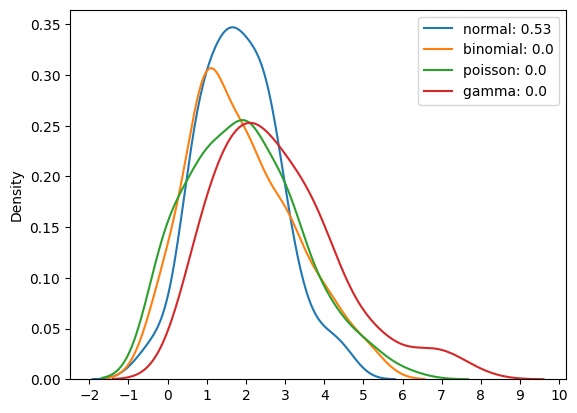

In [ ]:
from numpy.lib import bincount
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats

n = 100
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

# normal
norm = np.random.normal(2, 1, size=n)
sns.kdeplot(norm, label=f'normal: {round(stats.shapiro(norm).pvalue,2)}', ax=ax)

# binomial
bino = np.random.binomial(10, .2, size=n)
sns.kdeplot(bino, label=f'binomial: {round(stats.shapiro(bino).pvalue,2)}', ax=ax)

# poisson
pois = np.random.poisson(2, n)
sns.kdeplot(pois, label=f'poisson: {round(stats.shapiro(pois).pvalue,2)}', ax=ax)

# gamma
gamma = np.random.gamma(3, 1, n)
sns.kdeplot(gamma, label=f'gamma: {round(stats.shapiro(gamma).pvalue,2)}', ax=ax)

plt.legend();

### Probability Density Function

* When normal, we get significance, confidence, p-values, power, alpha, z-scores, etc
* When not normal, normal pdf won't work, e.g., for a Poisson distribution use the Poisson pdf (stats.poisson.pdf) (cdf, ppf, pmf, etc)
* What is a distribution appropriate for social media when trying to make inferences back the whole population?
* The probabilities associated with extreme values on a normal distribution will probably not be the same for other distributions (beta, poisson, gamma, etc)

### Practical Examples of Distributions

* Normal: natural phenomena of one variate
* Binomial: counting, gambling
* Poisson: events happening in a period of time
* Gamma: time to failure in mechanics, reliability in a piece of technology

# Generalized Linear Models


## Model Responses

Quantitative Response

* $y = \theta^T X + \epsilon_i$ (matrix form)
* where $\epsilon \overset{iid}{\sim} \mathcal{N}(0, \sigma^2)$
* and $\epsilon$ is model noise and generally unknown

Binary Response

* $p(y=1) = \Large\frac{1}{1 + e^{-(\theta^T X)}}$

Generalized Linear Model

* Other responses include non-negative, skewed, etc
* Framework for different response types
* Useful when models violate assumptions
* See Assumptions Notebook



In [ ]:
# test of normality
from sklearn.datasets import make_regression
import scipy.stats as stats

for _ in range(0, 10):
  X, y = make_regression(n_samples=1000, n_features=10, n_informative=6)
  print(stats.shapiro(y))

cnt = 0
for _ in range(0, 100):
  X, y = make_regression(n_samples=1000, n_features=1)
  if stats.shapiro(y).pvalue >= .05 and stats.shapiro(X).pvalue >= .05:
    cnt += 1

print()
print(cnt)

ShapiroResult(statistic=0.9977561235427856, pvalue=0.19491177797317505)
ShapiroResult(statistic=0.9988417029380798, pvalue=0.7816078066825867)
ShapiroResult(statistic=0.9979389309883118, pvalue=0.25799670815467834)
ShapiroResult(statistic=0.9980266094207764, pvalue=0.29395076632499695)
ShapiroResult(statistic=0.9985963702201843, pvalue=0.6186116933822632)
ShapiroResult(statistic=0.9984888434410095, pvalue=0.5473707318305969)
ShapiroResult(statistic=0.9965619444847107, pvalue=0.02763977088034153)
ShapiroResult(statistic=0.9967437982559204, pvalue=0.03736698254942894)
ShapiroResult(statistic=0.9988268613815308, pvalue=0.7721854448318481)
ShapiroResult(statistic=0.9987184405326843, pvalue=0.7009420394897461)

94


## The General Linear Model

$y = \beta_0 + \beta_1 X + e$ or Outcome = Intercept + Slope x Predictor + $e$

* $y = \beta_0 + e$: one sample t test
* $y = \beta_0 + \beta_1 Group + e$: independent t
* $y1 - y2 = \beta_0 + e$: paired
* $y = \beta_0 + \beta_1 Group_1 + \beta_2 Group_2 + e$: anova

Intercepts and Slopes vs Means and Mean Differences

* Intercept $\sim$ Mean
* Slope $\sim$ Mean Differences

### Generalized Linear Model Components

* Random Component - probability distribution
* Systematic Component - coefficients + explanatory variables
* Link Function - transforms (relates) the mean to the explanatory variables

### Model Parameters

* Gaussian (mean ($\mu$) and variance ($\sigma^2$))
* Binomial (independent trials ($n$) and success ($p$))
* Poisson Regression Model (mean and variance are equal)
* Gamma ($\alpha$ = shape, $\beta$ = rate)
* Negative-Binomial (similar to Poisson but uses $\alpha$ as a shape parameter)
* Inverse Gaussian (mean ($\mu$) and shape ($\lambda$)

## Link Functions

Allows the linear model to be related to the response variable by transforming the output of the response to fit the model boundaries.

$\eta$ = link

* linear: $\eta (\mu) = \mu$
* logistic: $\eta(\mu) = log(\mu/(1-\mu))$
* poisson: $\eta(\mu) = log(\mu)$

The link function is a crucial component of a Generalized Linear Model (GLM). It provides the connection between the linear predictor (a linear combination of the predictors) and the expected value of the response variable.  Think of it as a translator that allows you to model different types of response variables within a linear framework.

Here's a breakdown of what the link function does and why it's important:

**1. Linear Predictor**

In a GLM, you have a linear predictor, which is simply a weighted sum of your predictor variables (features). It looks like this:

  `linear predictor = b0 + b1*x1 + b2*x2 + ...`

where:

* `b0`, `b1`, `b2`, etc. are the coefficients estimated by the model.
* `x1`, `x2`, etc. are the predictor variables.

**2.  Connecting to the Response**

The link function takes this linear predictor and transforms it to match the expected value of the response variable. This is necessary because the response variable might not have a linear relationship with the predictors and might have specific constraints.

**3.  Examples of Link Functions**

* **Identity link:** `g(μ) = μ` (no transformation) - Used for continuous data with a normal distribution (simple linear regression).
* **Logit link:** `g(μ) = log(μ / (1 - μ))` - Used for binary data (logistic regression). It maps probabilities (between 0 and 1) to a range from negative to positive infinity.
* **Log link:** `g(μ) = log(μ)` - Used for count data (Poisson regression) or continuous positive data. It ensures the predicted values are positive.
* **Inverse link:** `g(μ) = 1 / μ` - Used when the response is inversely proportional to the linear predictor.

**4.  Why is the Link Function Important?**

* **Flexibility:** It allows GLMs to model various types of response variables (continuous, binary, count, etc.) within a unified framework.
* **Interpretability:** It provides a meaningful way to interpret the relationship between the predictors and the response variable on a suitable scale.
* **Statistical Properties:**  It ensures that the model's predictions satisfy the properties of the chosen response distribution.

**5. Choosing the Link Function**

The choice of link function depends on the nature of your response variable and the assumptions you're making about its distribution. Here's a general guideline:

* **Normally distributed:** Identity link
* **Positive skewed data:** Log link
* **Binary data:** Logit link
* **Count data:** Log link

**In summary:**

The link function is a key component of a GLM that connects the linear predictor to the expected value of the response variable. It allows you to model different types of response variables and ensures that the model's predictions are meaningful and statistically sound.


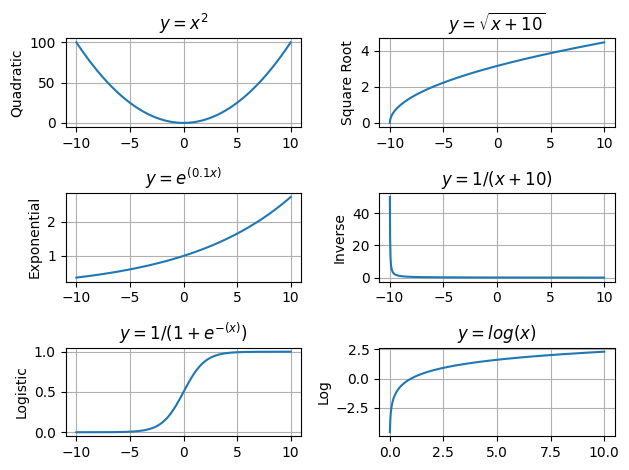

In [ ]:
# link functions
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

fig = plt.figure()
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)

x = np.linspace(-10, 10, 1000)

y = x ** 2
ax1.grid()
ax1.plot(x, y)
ax1.title.set_text(r'$y=x^2$')
# ax1.title.set_text('y=x^2')
ax1.set_ylabel('Quadratic')

y = np.sqrt(x+10)
ax2.grid()
ax2.plot(x, y)
ax2.title.set_text(r'$y=\sqrt{x+10}$')
# ax2.title.set_text('y=sqrt(x)')
ax2.set_ylabel('Square Root')

y = np.e**(0.1*x)
ax3.grid()
ax3.plot(x, y)
ax3.title.set_text(r'$y=e^{(0.1x)}$')
# ax3.title.set_text('y=e^(0.1x)')
ax3.set_ylabel('Exponential')

y = 1/(x+10)
ax4.grid()
ax4.plot(x, y)
ax4.title.set_text(r'$y=1/(x+10)$')
# ax4.title.set_text('y=1/(x+10)')
ax4.set_ylabel('Inverse')

y = 1/(1 + np.e**-(x))
ax5.grid()
ax5.plot(x, y)
ax5.title.set_text(r'$y=1/(1+e^{-(x)})$')
# ax5.title.set_text('y=1/(1+e^-(x)')
ax5.set_ylabel('Logistic')

y = np.log(x)
ax6.grid()
ax6.plot(x, y)
ax6.title.set_text(r'$y=log(x)$')
# ax6.title.set_text('y=log(x)')
ax6.set_ylabel('Log')

plt.tight_layout();

## Family

The `family` parameter in a Generalized Linear Model (GLM) is crucial because it specifies the **probability distribution** of your response variable (the variable you're trying to predict). This distribution determines the relationship between the linear predictor (a combination of predictors and coefficients) and the expected value of the response.

Here's a breakdown of why the `family` parameter is important and how it works:

**1.  Connecting the Linear Predictor to the Response**

In a GLM, the link function connects the linear predictor to the response variable. However, the link function alone doesn't fully define the relationship. The `family` parameter specifies the distribution of the response, which, in conjunction with the link function, determines how the linear predictor is related to the expected value of the response.

**2.  Common Families and Their Uses**

Here are some common families used in GLMs:

* **Gaussian (Normal):**  Used for continuous data that is normally distributed. This is the default family for many GLM implementations.
* **Binomial:** Used for binary data (e.g., success/failure, presence/absence) or count data where the number of trials is fixed.
* **Poisson:** Used for count data where the events occur independently at a constant rate (e.g., the number of customers arriving at a store per hour).
* **Gamma:** Used for continuous positive data that is skewed (e.g., income, waiting times).
* **Inverse Gaussian:**  Used for continuous positive data with a specific type of skewness.

**3.  Choosing the Right Family**

The choice of family depends on the nature of your response variable and the assumptions you're willing to make about its distribution. Here's a general guideline:

* **Normally distributed:** Gaussian family
* **Skewed positive data:** Gamma or Inverse Gaussian family
* **Binary data:** Binomial family
* **Count data:** Poisson family

**4.  Example: `statsmodels` in Python**

In `statsmodels`, you specify the family using the `family` argument in the `GLM` class. For example:

```python
import statsmodels.api as sm

# Fit a GLM with a Gaussian family and identity link (default)
model = sm.GLM(y, X, family=sm.families.Gaussian())
```

This code specifies a Gaussian family for the response variable `y`. You can change the family to `sm.families.Binomial()`, `sm.families.Poisson()`, etc., depending on your data.

**Key Takeaways**

* The `family` parameter in a GLM determines the probability distribution of the response variable.
* It works in conjunction with the link function to define the relationship between the linear predictor and the response.
* Choosing the appropriate family is crucial for building a valid and meaningful GLM.
* The choice of family should be based on the nature of your response variable and the assumptions you're making about its distribution.


### Simple Linear Regression

See GLM v OLS Notebook

The link function for simple linear regression is the **identity function**.

Here's why:

* **GLMs and Link Functions:** Generalized Linear Models (GLMs) extend traditional linear regression to accommodate various types of response variables (continuous, binary, counts, etc.).  A key component of a GLM is the *link function*, which establishes a connection between the linear predictor (the familiar $mx + b$ in simple linear regression) and the expected value of the response variable.

* **Identity Function:** The identity function is simply a function that returns its input unchanged.  Mathematically, it's represented as  $f(x) = x$.

* **Simple Linear Regression:** In simple linear regression, we're modeling a continuous response variable with a normal distribution.  The expected value of the response variable is directly equal to the linear predictor.  In other words, we don't need any transformation to map the linear predictor to the expected value.  This "no transformation" is precisely what the identity function accomplishes. The identity link function in simple linear regression preserves the linear relationship between the predictor and the response variable. It's the simplest and most direct way to model this type of relationship within the GLM framework.

**In summary:** The identity link function in simple linear regression implies that the predicted value from the linear equation ($mx + b$) is directly used as the expected value of the response variable.


### Quadratic Function

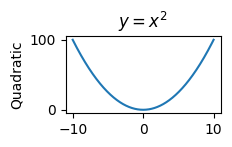

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(2,1))
x = np.linspace(-10, 10, 1000)
y = x ** 2
plt.plot(x, y)
plt.title(r'$y=x^2$')
plt.ylabel('Quadratic')
plt.show()


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          87.959
Method:                          IRLS   Log-Likelihood:                -364.21
Date:                Fri, 25 Oct 2024   Deviance:                       8532.0
Time:                        12:59:16   Pearson chi2:                 8.53e+03
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8058      1.407     -2.705      0.0

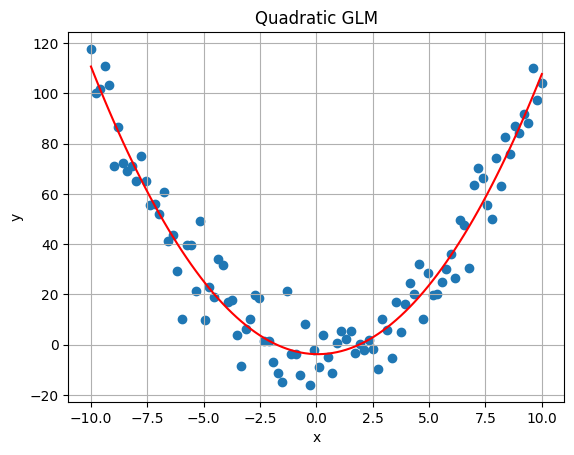

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate data and set variables
np.random.seed(0)
title = 'Quadratic GLM'
family = sm.families.Gaussian()
link_function = lambda x: x**2
x = np.linspace(-10, 10, 100)
y = link_function(x) + np.random.normal(0, 10, 100)  # Add some noise

# GLM modeling
X = np.column_stack((x, link_function(x)))
X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.GLM(y, X, family=family).fit()
predictions = model.predict(X)
print(model.summary())

# Plot the data and the fitted curve (predictions)
plt.scatter(x, y)
plt.plot(x, predictions, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{title}')
plt.grid(True)
plt.show()

### Square Root Function

x values must be non-negative for sqrt

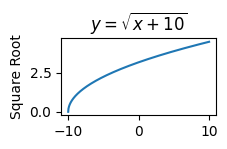

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(2,1))
x = np.linspace(-10, 10, 1000)
y = np.sqrt(x+10)
plt.plot(x, y)
plt.title(r'$y=\sqrt{x+10}$')
plt.ylabel('Square Root')
plt.show()

<ipython-input-72-7ac982107e0e>:19: RuntimeWarning: invalid value encountered in sqrt
  predictions = np.sqrt(y_pred_transformed) # Take the square root


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          9.3273
Method:                          IRLS   Log-Likelihood:                -252.53
Date:                Fri, 25 Oct 2024   Deviance:                       914.08
Time:                        12:59:03   Pearson chi2:                     914.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9792
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.2572      0.305     33.585      0.0

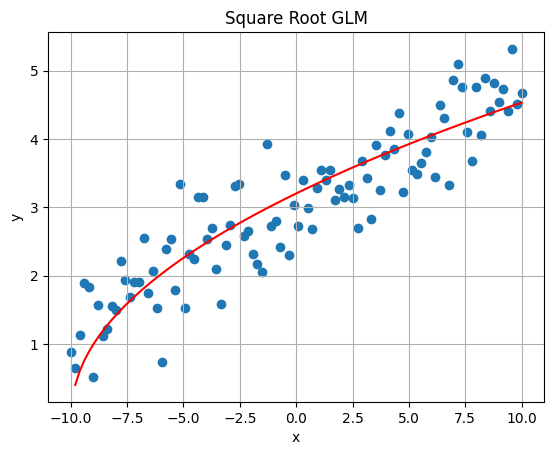

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate data and set variables
np.random.seed(0)
title = 'Square Root GLM'
family = sm.families.Gaussian()
link_function = lambda x: np.sqrt(x+10)
x = np.linspace(-10, 10, 100)  # x values must be non-negative for sqrt
y = link_function(x) + np.random.normal(0, 0.5, 100)  # Add some noise

# GLM modeling
X = sm.add_constant(x)  # Add a constant for the intercept
# statsmodels doesn't directly support a square root link function for the Gaussian family
y_transformed = y ** 2  # Square the y values
model = sm.GLM(y_transformed, X, family=family).fit()
y_pred_transformed = model.predict(X) # make predictions (on the transformed scale)
predictions = np.sqrt(y_pred_transformed) # Take the square root
print(model.summary())

# Plot the data and the fitted curve (predictions on the original scale)
plt.scatter(x, y)
plt.plot(x, predictions, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'{title}')
plt.grid(True)
plt.show()

Why y transformation is necessary:

* **Desired Relationship:** The code aims to model a square root relationship between `x` and `y`, as indicated by the `link_function = lambda x: np.sqrt(x+10)`. This means that `y` should increase roughly as the square root of `x`.

* **Limitations of `statsmodels`:**  While `statsmodels` provides a flexible framework for GLMs, it doesn't directly support a square root link function for the Gaussian family.

* **Transformation as a Solution:** To overcome this limitation, the code applies a transformation to the response variable (`y`) *before* fitting the GLM. By squaring `y` (`y_transformed = y ** 2`), the relationship between `x` and `y_transformed` becomes approximately linear.

* **Fitting a Linear Model:** Now that the relationship is linear on the transformed scale, a standard GLM with an identity link function can be used to model the data effectively.

* **Back-Transformation:** After fitting the model and making predictions on the transformed scale (`y_pred_transformed`), the code applies the inverse transformation (square root) to get predictions on the original scale of `y` (`predictions = np.sqrt(y_pred_transformed)`).

**In essence:**

Transforming `y` allows you to model a non-linear (square root) relationship using a linear model (GLM with identity link). It's a common technique in statistics when the desired relationship doesn't directly fit into the available model framework.

This approach demonstrates the flexibility of GLMs and how transformations can be used to extend their capabilities to model various types of relationships.


### Exponential Function

family=sm.families.Gaussian(link=sm.families.links.log())

/usr/local/lib/python3.10/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:                    log   Scale:                        0.041113
Method:                          IRLS   Log-Likelihood:                 18.678
Date:                Fri, 25 Oct 2024   Deviance:                       4.0291
Time:                        12:39:59   Pearson chi2:                     4.03
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0101      0.025     -0.403      0.6

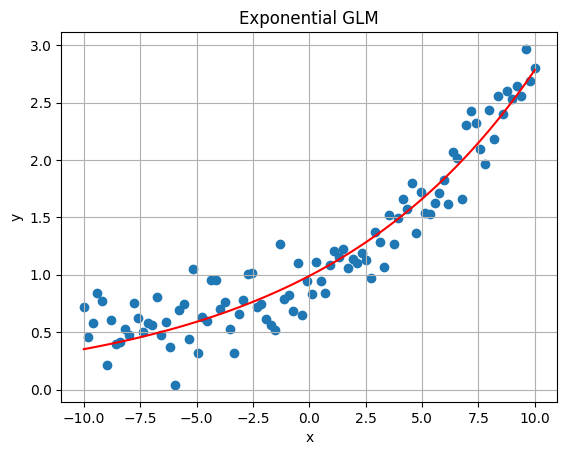

In [ ]:
# import numpy as np
# import statsmodels.api as sm
# import matplotlib.pyplot as plt

# link_function = lambda x: np.exp(0.1 * x)

# # Generate data with an exponential relationship
# np.random.seed(0)
# x = np.linspace(-10, 10, 100)
# y = link_function(x) + np.random.normal(0, 0.2, 100)  # Add some noise

# # Create the design matrix
# X = sm.add_constant(x)

# # Fit the GLM with a Gaussian family and exponential link function
# model = sm.GLM(y, X, family=sm.families.Gaussian(link=sm.families.links.log()))
# results = model.fit()

# # Print the model summary
# print(results.summary())

# # Make predictions
# predictions = results.predict(X)

# # Plot the data and the fitted curve
# def plot_GLM(x, y, predictions, title):
#   plt.scatter(x, y)
#   plt.plot(x, predictions, color='red')
#   plt.xlabel('x')
#   plt.ylabel('y')
#   plt.title('Exponential GLM')
#   plt.grid(True)
#   plt.show()

#   return None

# plot_GLM(x, y, predictions, title)

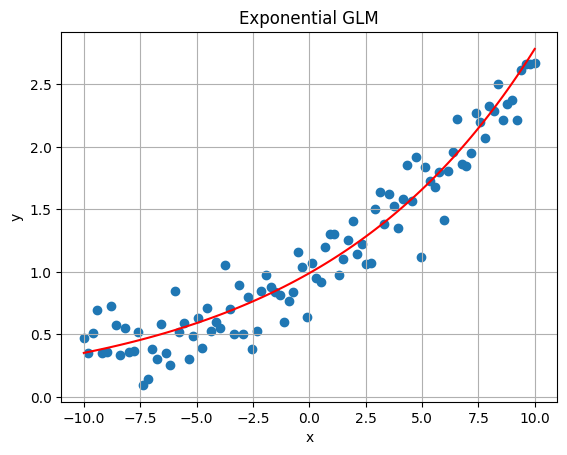

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:                    Log   Scale:                        0.033307
Method:                          IRLS   Log-Likelihood:                 29.206
Date:                Fri, 25 Oct 2024   Deviance:                       3.2641
Time:                        12:59:53   Pearson chi2:                     3.26
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0261      0.023     -1.140      0.2

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate data and set variables
np.random.seed(42)
title = 'Exponential GLM'
family = sm.families.Gaussian(link=sm.families.links.Log())
link_function = lambda x: np.exp(0.1 * x)
x = np.linspace(-10, 10, 100)  # x values must be non-negative for sqrt
y = link_function(x) + np.random.normal(0, 0.2, 100)  # Add some noise

# GLM modeling
def model_GLM(x, y, family):
  X = sm.add_constant(x)
  model = sm.GLM(y, X, family=family).fit()
  predictions = model.predict(X)
  return model, predictions

# Plot the data and the fitted curve
def plot_GLM(x, y, predictions, title):
  plt.scatter(x, y)
  plt.plot(x, predictions, color='red')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(f'{title}')
  plt.grid(True)
  plt.show()
  return None

plot_GLM(x, y, predictions, title)
model, predictions = model_GLM(x, y, family)
print(model.summary())


In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# GLM modeling
def model_GLM(x, y, family):
  X = sm.add_constant(x)
  model = sm.GLM(y, X, family=family).fit()
  predictions = model.predict(X)
  return model, predictions

# Plot the data and the fitted curve
def plot_GLM(x, y, predictions, title):
  plt.scatter(x, y)
  plt.plot(x, predictions, color='red')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title(f'{title}')
  plt.grid(True)
  plt.show()
  return None

### Inverse Function



In [ ]:
# import numpy as np
# import statsmodels.api as sm
# import matplotlib.pyplot as plt

# link_function = lambda x: 1 / (x + 10)

# # Generate data with an inverse relationship
# np.random.seed(0)
# x = np.linspace(0, 100, 100)
# y = link_function(x) + np.random.normal(0, 0.2, 100)  # Add some noise

# # Create the design matrix
# X = sm.add_constant(x)

# # Fit the GLM with a Gaussian family and inverse_power link function
# model = sm.GLM(y, X, family=sm.families.Gaussian(link=sm.families.links.inverse_power()))
# results = model.fit()

# # Print the model summary
# print(results.summary())

# # Make predictions
# y_pred = results.predict(X)

# # Plot the data and the fitted curve
# plt.scatter(x, y, alpha=0.5)
# plt.plot(x, y_pred, color='red')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Inverse Relationship GLM')
# plt.grid(True)
# plt.show()

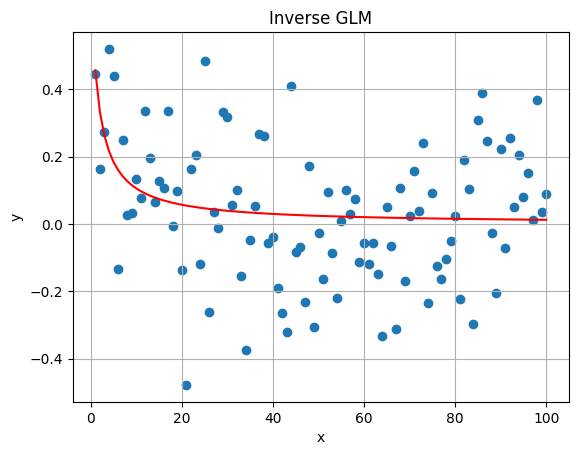

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:           InversePower   Scale:                        0.038447
Method:                          IRLS   Log-Likelihood:                 22.030
Date:                Fri, 25 Oct 2024   Deviance:                       3.7678
Time:                        13:04:15   Pearson chi2:                     3.77
No. Iterations:                    12   Pseudo R-squ. (CS):             0.1241
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4146      1.101      1.285      0.1

In [ ]:
np.random.seed(0)
title = 'Inverse GLM'
family = sm.families.Gaussian(link=sm.families.links.InversePower())
link_function = lambda x: 1/(x+10)
x = np.linspace(1, 100, 100)
y = link_function(x) + np.random.normal(0, 0.2, 100)  # Add some noise

plot_GLM(x, y, predictions, title)
model, predictions = model_GLM(x, y, family)
print(model.summary())

### Logistic Function

In [ ]:
# import numpy as np
# import statsmodels.api as sm
# import matplotlib.pyplot as plt

# link_function = lambda x: 1 / (1 + np.exp(-x))

# # Generate data with a logistic relationship
# np.random.seed(0)
# x = np.linspace(-10, 10, 100)
# y = link_function(x) + np.random.normal(0, 0.05, 100)  # Add some noise
# # Ensure y values are within (0, 1) for the logistic model
# y = np.clip(y, 0.001, 0.999)

# # Create the design matrix
# X = sm.add_constant(x)

# # Fit the GLM with a Binomial family and logit link function
# model = sm.GLM(y, X, family=sm.families.Binomial())  # Logit link is default for Binomial
# results = model.fit()

# # Print the model summary
# print(results.summary())

# # Make predictions
# y_pred = results.predict(X)

# # Plot the data and the fitted curve
# plt.scatter(x, y, alpha=0.5)
# plt.plot(x, y_pred, color='red')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Logistic GLM')
# plt.grid(True)
# plt.show()

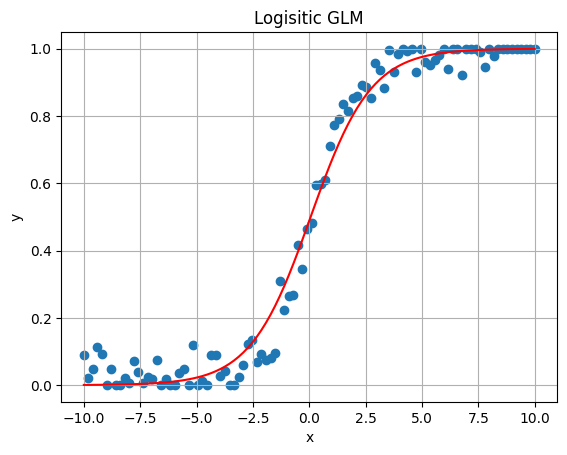

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18.434
Date:                Fri, 25 Oct 2024   Deviance:                       6.3513
Time:                        13:07:42   Pearson chi2:                     21.4
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5907
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011      0.365     -0.003      0.9

In [ ]:
np.random.seed(0)
title = 'Logisitic GLM'
family = sm.families.Binomial()
link_function = lambda x: 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 100)
y = link_function(x) + np.random.normal(0, 0.05, 100)  # Add some noise
y = np.clip(y, 0.001, 0.999)

plot_GLM(x, y, predictions, title)
model, predictions = model_GLM(x, y, family)
print(model.summary())

### Log Function

In [ ]:
# import numpy as np
# import statsmodels.api as sm
# import matplotlib.pyplot as plt

# # Generate data with a logarithmic relationship
# np.random.seed(0)
# x = np.linspace(0.1, 10, 100)  # x values must be positive for log
# y = np.log(x) + np.random.normal(0, 0.5, 100)  # Add some noise

# # Create the design matrix
# X = sm.add_constant(x)

# # Fit the GLM with a Gaussian family and log link function
# model = sm.GLM(y, X, family=sm.families.Gaussian(link=sm.families.links.log()))
# results = model.fit()

# # Print the model summary
# print(results.summary())

# # Make predictions
# y_pred = results.predict(X)

# # Plot the data and the fitted curve
# plt.scatter(x, y, alpha=0.5)
# plt.plot(x, y_pred, color='red')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Logarithmic GLM')
# plt.grid(True)
# plt.show()

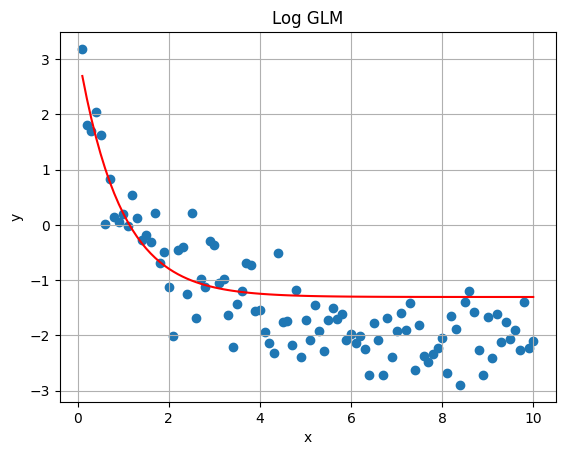

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:                    Log   Scale:                         0.38454
Method:                          IRLS   Log-Likelihood:                -93.108
Date:                Fri, 25 Oct 2024   Deviance:                       37.685
Time:                        13:54:28   Pearson chi2:                     37.7
No. Iterations:                    10   Pseudo R-squ. (CS):             0.8022
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3561      0.118     11.530      0.0

In [ ]:
np.random.seed(0)
title = 'Log GLM'
family = sm.families.Gaussian(link=sm.families.links.Log())
link_function = lambda x: -np.log(x)
x = np.linspace(0.1, 10, 100)
y = link_function(x) + np.random.normal(0, 0.5, 100)  # Add some noise

y_scaled = (y - np.mean(y)) / np.std(y)
model, preds = model_GLM(x, y_scaled, family)
predictions = preds * np.std(y) + np.mean(y)
plot_GLM(x, y, predictions, title)
print(model.summary())

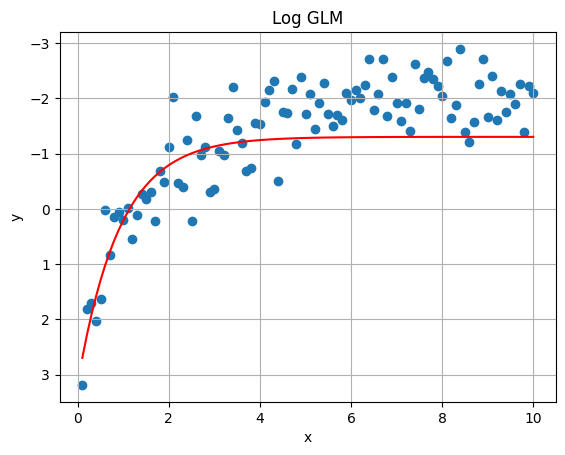

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                Gaussian   Df Model:                            1
Link Function:                    Log   Scale:                         0.38454
Method:                          IRLS   Log-Likelihood:                -93.108
Date:                Fri, 25 Oct 2024   Deviance:                       37.685
Time:                        13:53:38   Pearson chi2:                     37.7
No. Iterations:                    10   Pseudo R-squ. (CS):             0.8022
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3561      0.118     11.530      0.0

In [ ]:
# Plot the data and the fitted curve
def invert_plot_GLM(x, y, predictions, title):
  fig, ax = plt.subplots()
  ax.scatter(x, y)
  ax.plot(x, predictions, color='red')
  ax.invert_yaxis()
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_title(f'{title}')
  ax.grid(True)
  plt.show()
  return None

np.random.seed(0)
title = 'Log GLM'
family = sm.families.Gaussian(link=sm.families.links.Log())
link_function = lambda x: -np.log(x)
x = np.linspace(0.1, 10, 100)
y = link_function(x) + np.random.normal(0, 0.5, 100)  # Add some noise

y_scaled = (y - np.mean(y)) / np.std(y)
model, preds = model_GLM(x, y_scaled, family)
predictions = preds * np.std(y) + np.mean(y)
invert_plot_GLM(x, y, predictions, title)
print(model.summary())

**Basis Functions**

* **Purpose:** To model the relationship between the predictors (independent variables) and the response variable. They determine the *shape* of the relationship.
* **How they work:**
    * They are building blocks for creating flexible functions.
    * They are combined linearly with coefficients to create complex curves.
    * Examples: Polynomials, splines, radial basis functions.
* **Where they operate:** They work on the *predictor side* of the equation, transforming the input variables before they are used to predict the response.

**Link Functions**

* **Purpose:** To connect the linear predictor (a combination of predictors and coefficients) to the expected value of the response variable. They determine how the *scale* of the response is related to the linear predictor.
* **How they work:**
    * They are typically non-linear functions.
    * They map the linear predictor to a suitable range for the response variable (e.g., probabilities for logistic regression, positive values for Poisson regression).
    * Examples: Logit, probit, log, inverse.
* **Where they operate:** They work on the *response side* of the equation, transforming the output of the linear predictor to match the characteristics of the response variable.

**Analogy**

Imagine you're building a house:

* **Basis functions** are like the different materials you use (wood, bricks, concrete). They determine the overall shape and structure of the house.
* **Link functions** are like the electrical wiring that connects the power source to the different rooms and appliances. They ensure that the electricity is delivered in a way that's compatible with each device.